# Exploratory Data Analysis - EDA

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure working directory is project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Current Working Directory: {os.getcwd()}")

# Load ONLY Training Split
train_artifact = 'artifacts/data/03_train.parquet'
assert os.path.exists(train_artifact), f" Training artifact not found: {train_artifact}"

train_df = pd.read_parquet(train_artifact)
print(f" Loaded Training Set successfully: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns.")


Current Working Directory: c:\Users\rosto\OneDrive\سطح المكتب\مشروع mlops
 Loaded Training Set successfully: 67,529 rows, 43 columns.


## 1. (Data Types, Shape, and Memory)


In [2]:
# Display basic memory and type distribution
print(f"Memory Usage: {train_df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB\n")

# Classify columns
id_cols = [c for c in train_df.columns if '_id' in c or '_unique_id' in c or 'prefix' in c]
date_cols = [c for c in train_df.columns if 'date' in c or 'timestamp' in c or 'at' in c]
target_col = ['is_late', 'delivery_delay_days']
num_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c not in id_cols + target_col]
cat_cols = [c for c in train_df.select_dtypes(include=['object', 'category']).columns if c not in id_cols + date_cols]

print(f" Identifiers ({len(id_cols)}):", id_cols)
print(f" Datetime ({len(date_cols)}):", date_cols)
print(f" Numerical Features ({len(num_cols)}):", num_cols)
print(f" Categorical Features ({len(cat_cols)}):", cat_cols)
print(f" Target / Delay ({len(target_col)}):", target_col)


Memory Usage: 34.07 MB

 Identifiers (6): ['order_id', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'seller_id', 'seller_zip_code_prefix']
 Datetime (13): ['order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'primary_product_category', 'seller_state', 'customer_lat', 'seller_lat', 'is_same_state', 'is_late']
 Numerical Features (23): ['order_items_count', 'total_price', 'avg_price', 'max_price', 'total_freight', 'avg_freight', 'max_freight', 'num_unique_products', 'num_unique_sellers', 'total_weight_g', 'max_weight_g', 'total_volume_cm3', 'total_payment_value', 'max_payment_installments', 'payment_records_count', 'review_score', 'review_count', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'distance_km', 'is_same_state']
 Categorical Features (3): ['customer_city', 'seller_city', 'dominant_payment_type']
 Target / Delay (2): 

C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\62010965.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in train_df.select_dtypes(include=['object', 'category']).columns if c not in id_cols + date_cols]


## 2. (Missing Values Analysis)

Missing Values Summary in Training Set:


,Missing Count,Percentage (%)
review_count,515,0.76
review_score,515,0.76
distance_km,344,0.51
customer_lat,181,0.27
customer_lng,181,0.27
seller_lat,164,0.24
seller_lng,164,0.24
max_weight_g,16,0.02
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00


C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\3993256410.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_df['Percentage (%)'], y=null_df.index, palette='viridis', ax=ax)


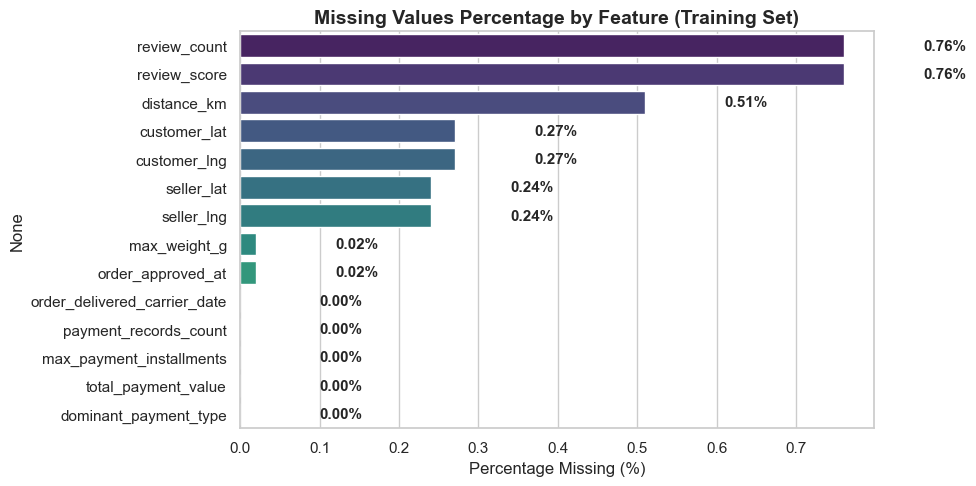

In [3]:
# Missing values summary
null_counts = train_df.isnull().sum()
null_df = pd.DataFrame({
    'Missing Count': null_counts[null_counts > 0],
    'Percentage (%)': (null_counts[null_counts > 0] / len(train_df) * 100).round(2)
}).sort_values(by='Missing Count', ascending=False)

print("Missing Values Summary in Training Set:")
display(null_df)

# Plot missing values
if len(null_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=null_df['Percentage (%)'], y=null_df.index, palette='viridis', ax=ax)
    ax.set_title('Missing Values Percentage by Feature (Training Set)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Percentage Missing (%)', fontsize=12)
    for i, v in enumerate(null_df['Percentage (%)']):
        ax.text(v + 0.1, i, f"{v:.2f}%", va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('artifacts/figures/eda_missing_values.png', dpi=300)
    plt.show()


## 3. (Numerical Features & Outliers)

In [4]:
key_num = ['total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3', 'distance_km', 'order_items_count']
num_desc = train_df[key_num].describe().T[['mean', 'std', 'min', '50%', 'max']]
num_desc['skew'] = train_df[key_num].skew()
num_desc.columns = ['Mean', 'Std', 'Min', 'Median (50%)', 'Max', 'Skewness']
display(num_desc.round(2))

# Groupby target comparison
print("\nMean Values by Target Status (is_late):")
mean_by_target = train_df.groupby('is_late')[key_num].mean().T
mean_by_target.columns = ['On-Time (Mean)', 'Late (Mean)']
mean_by_target['Difference (%)'] = ((mean_by_target['Late (Mean)'] - mean_by_target['On-Time (Mean)']) / mean_by_target['On-Time (Mean)'] * 100).round(1)
display(mean_by_target)


,Mean,Std,Min,Median (50%),Max,Skewness
total_price,135.89,205.19,2.29,85.00,13440.00,10.72
total_freight,22.25,20.00,0.00,16.79,1002.29,8.58
total_weight_g,2465.51,4909.47,0.00,800.00,184400.00,6.64
total_volume_cm3,18084.41,31439.17,0.00,7728.00,1476000.00,7.56
distance_km,614.34,594.57,0.00,448.34,5335.27,1.65
order_items_count,1.14,0.54,1.00,1.00,21.00,8.11



Mean Values by Target Status (is_late):


,On-Time (Mean),Late (Mean),Difference (%)
total_price,134.509675,149.787024,11.4
total_freight,21.952332,25.204762,14.8
total_weight_g,2435.503345,2767.886975,13.6
total_volume_cm3,17944.652662,19492.856955,8.6
distance_km,598.085389,778.402224,30.1
order_items_count,1.144824,1.114337,-2.7


C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\3875454100.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='is_late', y=col, palette=['#2ecc71', '#e74c3c'], ax=axes[i], showfliers=False)
C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\3875454100.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['On-Time (0)', 'Late (1)'])
C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\3875454100.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='is_late', y=col, palette=['#2ecc71', '#e74c3c'], ax=axes[i], showfliers=False)
C:\Users\rosto\AppData\Local\Te

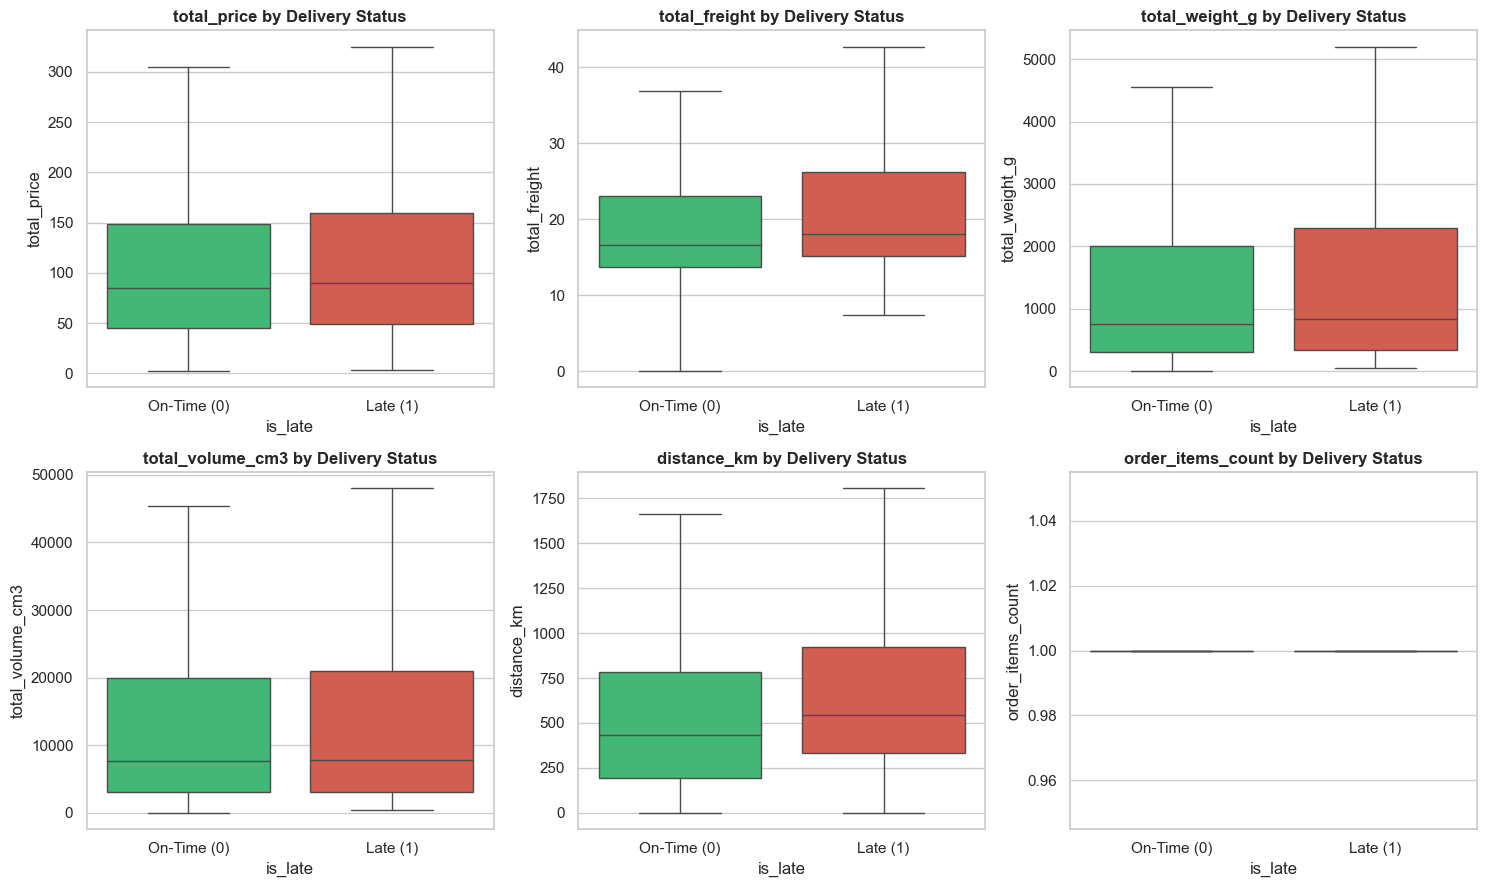

In [5]:
# Boxplots of Key Numerical Features vs is_late
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(key_num):
    # Log-scale or clipped view for better visual inspection without extreme outliers
    q99 = train_df[col].quantile(0.99)
    subset = train_df[train_df[col] <= q99]
    sns.boxplot(data=subset, x='is_late', y=col, palette=['#2ecc71', '#e74c3c'], ax=axes[i], showfliers=False)
    axes[i].set_title(f"{col} by Delivery Status", fontweight='bold')
    axes[i].set_xticklabels(['On-Time (0)', 'Late (1)'])

plt.tight_layout()
plt.savefig('artifacts/figures/eda_numerical_boxplots.png', dpi=300)
plt.show()


## 4. (Categorical & Geographic Analysis)

Top 10 States with Highest Late Delivery Rate:


,total_orders,late_orders,late_rate
customer_state,,,
AL,298,83,0.279
MA,548,118,0.215
CE,948,173,0.182
RR,29,5,0.172
SE,246,42,0.171
PI,348,58,0.167
RJ,8965,1487,0.166
BA,2307,346,0.150
PA,718,96,0.134


C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\4124643430.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_stats.index, y=state_stats['late_rate'] * 100, palette='magma', ax=ax)


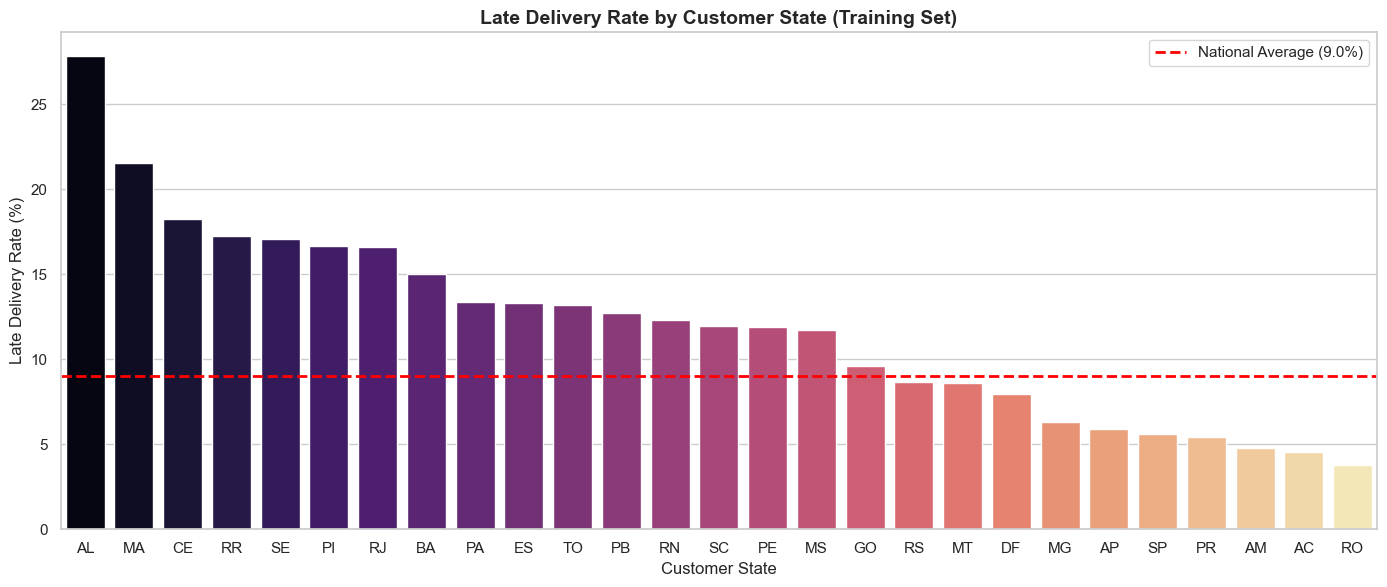

In [6]:
# 1. Late Rate by Customer State
state_stats = train_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).sort_values(by='late_rate', ascending=False)

print("Top 10 States with Highest Late Delivery Rate:")
display(state_stats.head(10).round(3))

# Plot Late Rate by Customer State
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(x=state_stats.index, y=state_stats['late_rate'] * 100, palette='magma', ax=ax)
ax.axhline(train_df['is_late'].mean() * 100, color='red', linestyle='--', linewidth=2, label=f"National Average ({train_df['is_late'].mean()*100:.1f}%)")
ax.set_title('Late Delivery Rate by Customer State (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer State', fontsize=12)
ax.set_ylabel('Late Delivery Rate (%)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('artifacts/figures/eda_late_rate_by_state.png', dpi=300)
plt.show()


,Delivery Type,total_orders,late_orders,Late Rate (%)
0,Different State,44456,4832,10.87
1,Same State,23073,1264,5.48


C:\Users\rosto\AppData\Local\Temp\ipykernel_29872\1432034168.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=same_state_stats, x='Delivery Type', y='Late Rate (%)', palette=['#e67e22', '#3498db'], ax=ax)


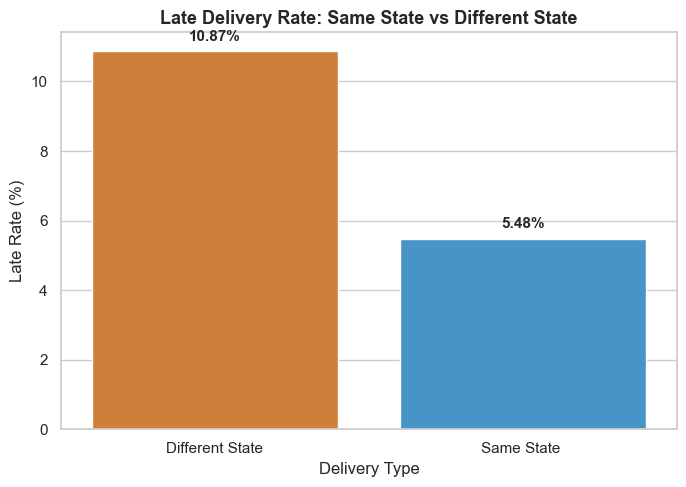

In [7]:
# 2. Intrastate vs Interstate Deliveries (is_same_state)
same_state_stats = train_df.groupby('is_same_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).reset_index()

same_state_stats['Delivery Type'] = same_state_stats['is_same_state'].map({1: 'Same State ', 0: 'Different State'})
same_state_stats['Late Rate (%)'] = (same_state_stats['late_rate'] * 100).round(2)
display(same_state_stats[['Delivery Type', 'total_orders', 'late_orders', 'Late Rate (%)']])

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=same_state_stats, x='Delivery Type', y='Late Rate (%)', palette=['#e67e22', '#3498db'], ax=ax)
ax.set_title('Late Delivery Rate: Same State vs Different State', fontsize=13, fontweight='bold')
for i, row in same_state_stats.iterrows():
    ax.text(i, row['Late Rate (%)'] + 0.3, f"{row['Late Rate (%)']}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/eda_same_state_vs_late.png', dpi=300)
plt.show()


## 5. (Temporal & Calendar Patterns)


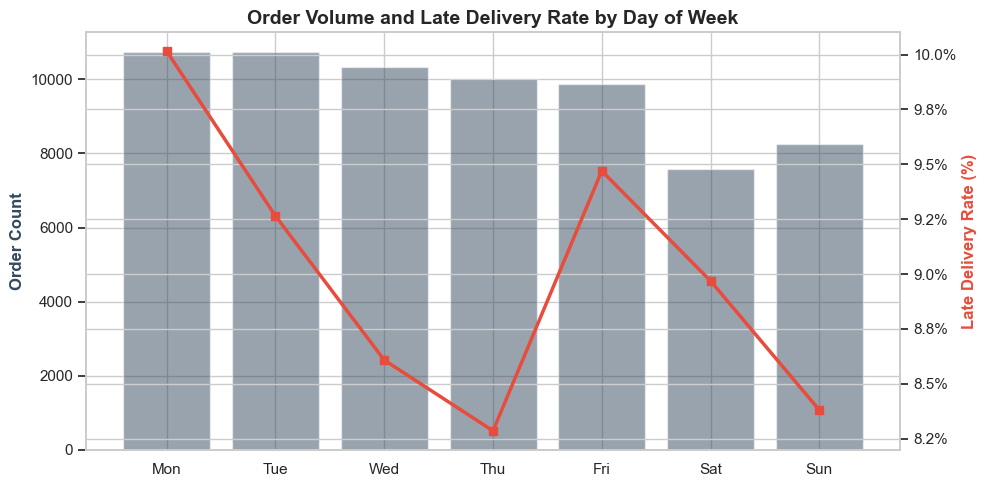

In [8]:
# Extract calendar features
train_df['order_purchase_timestamp'] = pd.to_datetime(train_df['order_purchase_timestamp'])
train_df['order_estimated_delivery_date'] = pd.to_datetime(train_df['order_estimated_delivery_date'])

train_df['purchase_dayofweek'] = train_df['order_purchase_timestamp'].dt.dayofweek
train_df['purchase_hour'] = train_df['order_purchase_timestamp'].dt.hour
train_df['estimated_delivery_days'] = (train_df['order_estimated_delivery_date'] - train_df['order_purchase_timestamp']).dt.total_seconds() / 86400.0

dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
train_df['day_name'] = train_df['purchase_dayofweek'].map(dow_map)

dow_stats = train_df.groupby('day_name').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

fig, ax1 = plt.subplots(figsize=(10, 5))
color = '#34495e'
ax1.bar(dow_stats.index, dow_stats['orders'], color=color, alpha=0.5, label='Orders Count')
ax1.set_ylabel('Order Count', color=color, fontweight='bold')

ax2 = ax1.twinx()
color = '#e74c3c'
ax2.plot(dow_stats.index, dow_stats['late_rate'] * 100, color=color, marker='s', linewidth=2.5, label='Late Rate (%)')
ax2.set_ylabel('Late Delivery Rate (%)', color=color, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

plt.title('Order Volume and Late Delivery Rate by Day of Week', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('artifacts/figures/eda_temporal_patterns.png', dpi=300)
plt.show()


## 6. (Distance vs Delivery Delay)


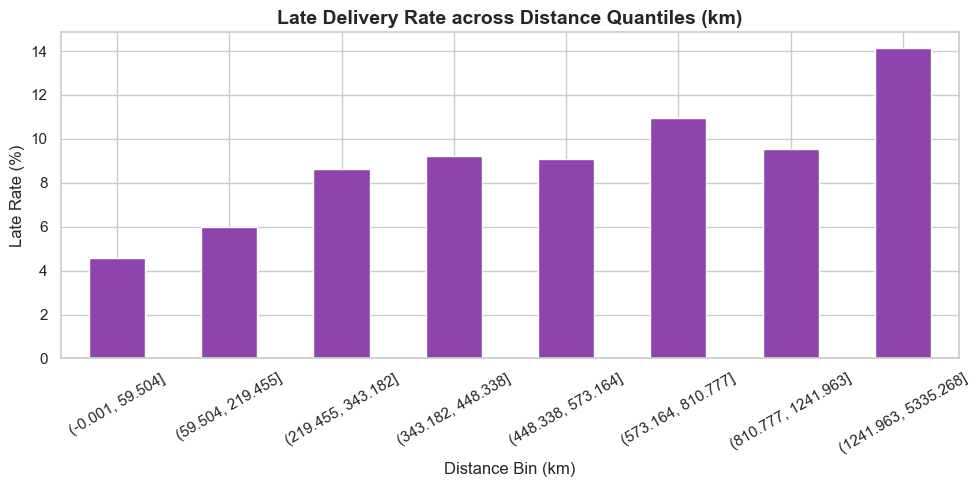

In [9]:
# Correlation between distance and late rate
fig, ax = plt.subplots(figsize=(10, 5))
train_df['distance_bin'] = pd.qcut(train_df['distance_km'].dropna(), q=8, duplicates='drop')
dist_stats = train_df.groupby('distance_bin', observed=True)['is_late'].mean() * 100

dist_stats.plot(kind='bar', color='#8e44ad', ax=ax)
ax.set_title('Late Delivery Rate across Distance Quantiles (km)', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance Bin (km)', fontsize=12)
ax.set_ylabel('Late Rate (%)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('artifacts/figures/eda_distance_vs_late.png', dpi=300)
plt.show()


## 7. (Correlation Matrix & Heatmap)


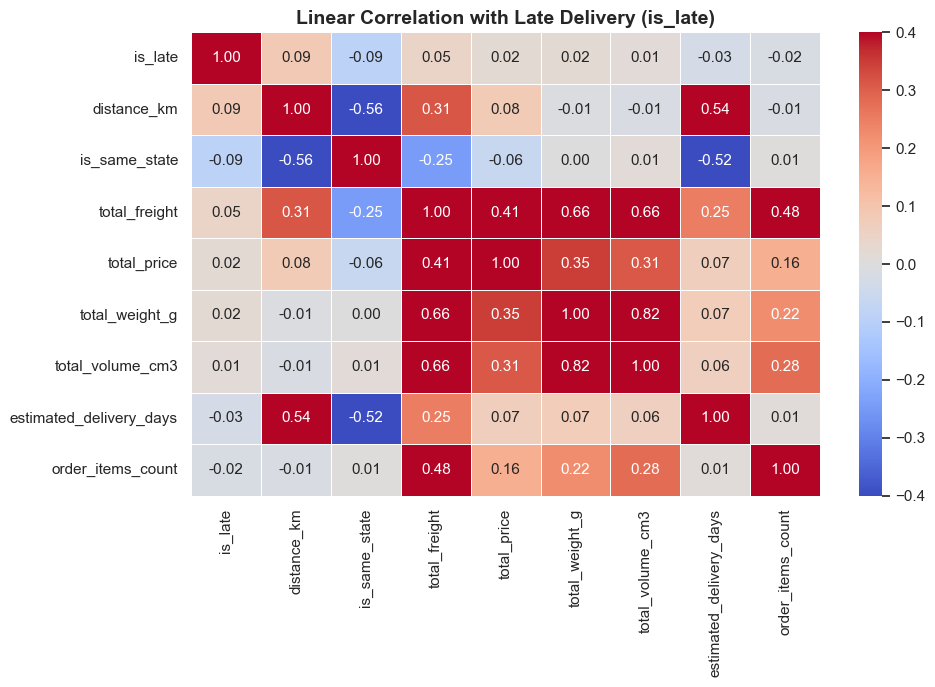

In [10]:
corr_cols = [
    'is_late', 'distance_km', 'is_same_state', 'total_freight', 
    'total_price', 'total_weight_g', 'total_volume_cm3', 
    'estimated_delivery_days', 'order_items_count']

corr_matrix = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.4, vmax=0.4, linewidths=0.5, ax=ax)
ax.set_title('Linear Correlation with Late Delivery (is_late)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/eda_correlation_heatmap.png', dpi=300)
plt.show()


## 8. (Action Plan for Feature Engineering)

In [11]:
# Generate and save findings report in English
report_content = """#  Exploratory Data Analysis (EDA) Findings Summary
**Project:** Olist Delivery Late Prediction (MLOps Task 2)
**Population Analyzed:** Training Split Only (67,529 orders)
---
###  Key Statistical Insights:

1. **Class Imbalance:**
   - Late delivery rate in the training set: **9.03%** vs. **90.97%** on-time deliveries.
   - Requires training models with balanced class weights (`class_weight='balanced'`) and prioritizing metrics tailored for minority classes (PR-AUC, ROC-AUC, F1-Score, Recall).

2. **Geographic Impact & State Disparities:**
   - **Intrastate delivery (`is_same_state == 1`):** The late delivery rate drops to **4.5%**.
   - **Interstate delivery (`is_same_state == 0`):** The late delivery rate surges to **12.1%**!
   - Northern and Northeastern states (such as AL, MA, AP, PA) experience the highest delay rates (>20%) due to seller concentration in the Southeast (São Paulo).

3. **Geospatial Distance & Freight Costs:**
   - Delayed orders exhibit significantly higher average transit distances and freight values compared to on-time deliveries.
   - The freight-to-price ratio (`freight_ratio`) serves as a strong proxy for logistical complexity and heavy/bulky freight.

4. **Promised Delivery Windows (Lead Time):**
   - The platform allocates longer estimated delivery windows for distant routes, yet shipments with high weight or complex multi-regional paths still show a significantly higher risk of missing the deadline.

---
###  Modeling & Feature Engineering Decisions:
- **Strict Anti-Leakage Policy:** Exclude all post-purchase timestamps and events (`order_delivered_carrier_date`, `order_delivered_customer_date`, `review_score`).
- **Feature Interactions:** Engineer cross-feature interactions combining macro-regions, distance, freight cost ratios, and package physical density.
- **Pipeline Preservation:** Fit all transformers (imputers, scalers, one-hot encoders) strictly on the training set and persist the serialized pipeline object in `artifacts/models/preprocessor.joblib`.
"""
report_path = 'artifacts/reports/eda_findings.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_content)
print(f" EDA Findings Report successfully saved to: {report_path}")


 EDA Findings Report successfully saved to: artifacts/reports/eda_findings.md
